In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784",version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
mnist["data"]

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
mnist["target"]

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [4]:
mnist["data"].shape

(70000, 784)

In [5]:
mnist["target"].shape

(70000,)

In [6]:
import numpy as np 
from matplotlib import pyplot as plt

In [7]:
data = mnist["data"]
target = mnist["target"]

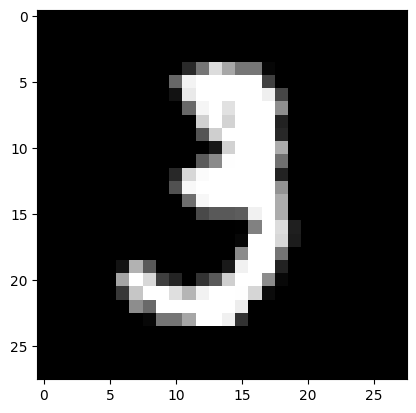

In [8]:
first_img = data.iloc[10,:].values
img = first_img.reshape(28,28)
plt.imshow(img, cmap="gray")

In [9]:
import torch
import torchvision.transforms as transforms
from torchvision.utils import save_image
from matplotlib import pyplot as plt
import cv2 as cv

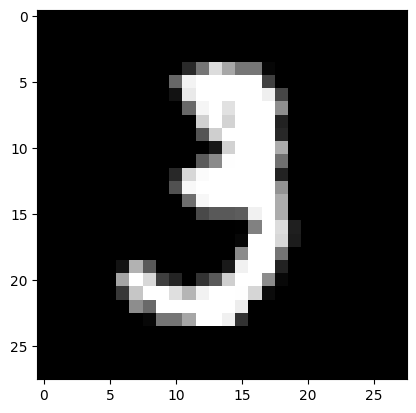

In [10]:
Horizontal_Flipping_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5) 
])
img = img.astype("uint8")
flipped_img = Horizontal_Flipping_Transformation(img)
plt.imshow(np.array(flipped_img), cmap="gray")

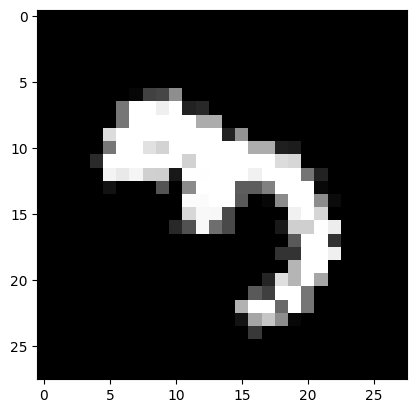

In [11]:
Rotate_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=66)
])

rotated_img = Rotate_Transformation(img)
plt.imshow(rotated_img,cmap="gray")

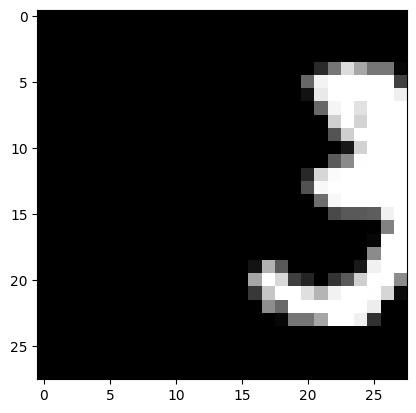

In [12]:
from scipy.ndimage import shift

shifted_img = shift(img, shift=[0, 10]) 
plt.imshow(shifted_img, cmap="gray")

In [49]:
import random
import pandas as pd 

def rand_rot_img_df(dataset,max_degree,min_degree,amount_of_rots):
    new_rows = []
    for i in range(3):
        img_cols = dataset.iloc[i,:].values
        img = img_cols.reshape(28,28)
        img = img.astype("uint8")
        for c in range(amount_of_rots):
            random_i = random.randint(int(max_degree),int(min_degree))
            Rotate_Transformation = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomRotation(degrees=random_i)
                ])
            rotated_img = Rotate_Transformation(img)
            img_flat = np.array(rotated_img).flatten()
            new_rows.append(pd.Series(img_flat, index=dataset.columns))
    augmented_df = pd.DataFrame(new_rows)
    return augmented_df

In [50]:
rand_rot_img_df(data,0,60,4)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
